In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

## What will project cover?:
1. Data Preprocessing
2. HOG feature extraction
3. Classical ML Models:
      - Logistic Regression
      - Support Vector Machine
      - Decision Tree
      - Random Forest
      - XGBoost
4. ANN
5. Custom CNN
6. Transfer Learning (VGG16)
7. Model evaluation and Comparison
8. Streamlit Inference
9. Streamlit Deployment

In [2]:
import os
import time
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow import nn

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [3]:
TRAIN_DATA_PATH = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
TEST_DATA_PATH = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"
IMAGE_SIZE = 64
BATCH_SIZE = 32
VALIDATION_SIZE = 0.2
MAX_IMAGES_PER_CLASS = 1000  # use at most 1000 images from each class; to use the complete training dataset: = None
RANDOM_STATE = 42
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [4]:
os.path.join(TRAIN_DATA_PATH, "buildings")

'/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/buildings'

In [5]:
os.listdir("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/buildings")[:10]

['2193.jpg',
 '11378.jpg',
 '10730.jpg',
 '17338.jpg',
 '16730.jpg',
 '10924.jpg',
 '15653.jpg',
 '19674.jpg',
 '1786.jpg',
 '7222.jpg']

In [6]:
os.path.join(os.path.join(TRAIN_DATA_PATH, "buildings"), "2193.jpg")

'/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/buildings/2193.jpg'

In [7]:
# A function to load the dataset
def load_data(data_path, class_names, image_size=64, max_images_per_class=None):
    images = []
    labels = []
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(data_path, class_name)
        if not os.path.exists(class_path):  # corner case #1
            print(f"Folder not found: {class_path}")
            continue
        image_names = os.listdir(class_path)
        random.shuffle(image_names)

        if max_images_per_class is not None:
            image_names = image_names[:max_images_per_class]

        for image_name in image_names:
            image_path = os.path.join(class_path, image_name)
            # read the image from its path --> OpenCV
            image = cv2.imread(image_path)
            if image is None: continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (image_size, image_size))
            images.append(image)
            labels.append(label)
        print(f"{class_name}: {len(image_names)} images loaded")
    return np.array(images), np.array(labels)

In [8]:
images, labels = load_data(
    data_path=TRAIN_DATA_PATH,
    class_names=CLASS_NAMES,
    image_size=IMAGE_SIZE,
    max_images_per_class=MAX_IMAGES_PER_CLASS
)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

buildings: 1000 images loaded
forest: 1000 images loaded
glacier: 1000 images loaded
mountain: 1000 images loaded
sea: 1000 images loaded
street: 1000 images loaded
Images shape: (6000, 64, 64, 3)
Labels shape: (6000,)


In [9]:
# A function to visualize a sample of training data
def visualize_images(images, labels, class_names, number_of_images=12):
    random_indices = np.random.choice(len(images), size=number_of_images)
    columns = 4
    rows = int(np.ceil(number_of_images/columns))
    plt.figure(figsize=(12, 3*rows))
    for pos, idx in enumerate(random_indices):
        plt.subplot(rows, columns, pos+1)
        plt.imshow(images[idx])
        plt.title(class_names[labels[idx]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

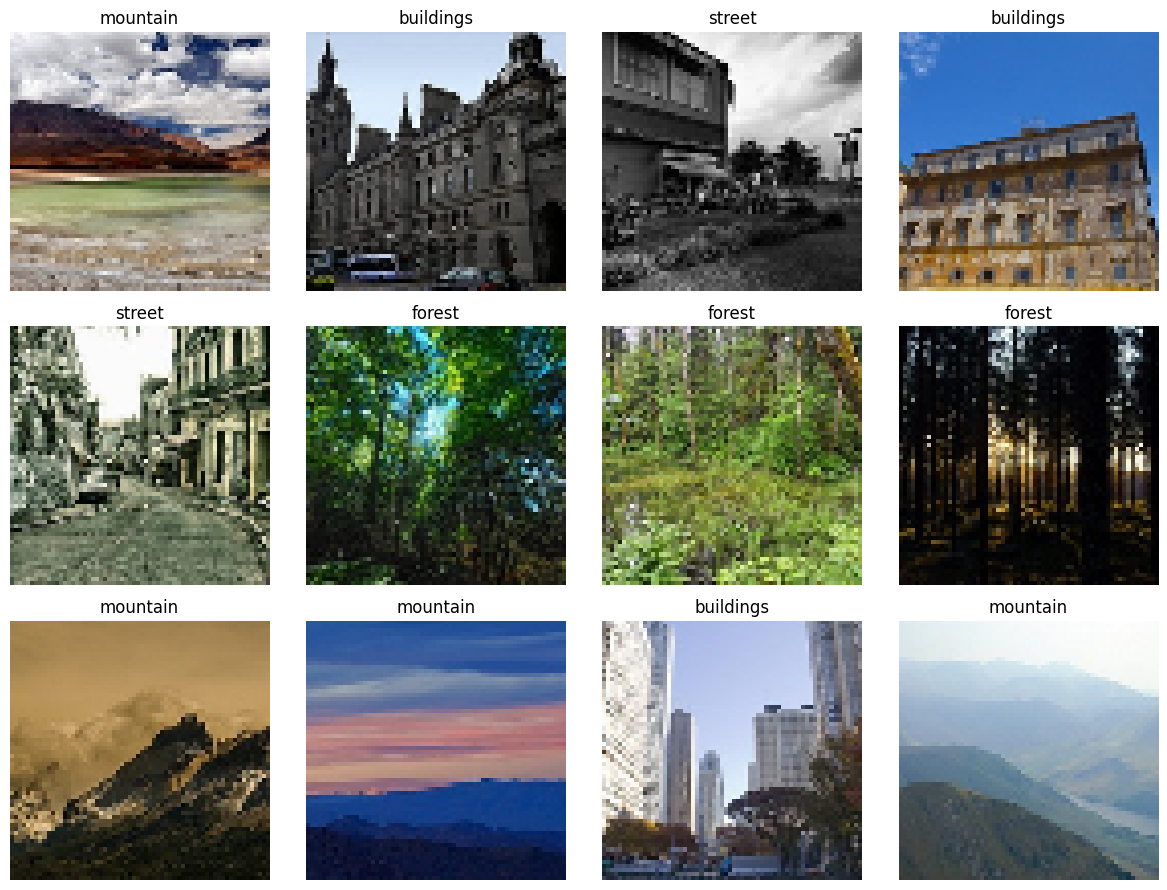

In [10]:
visualize_images(images, labels, CLASS_NAMES)

In [11]:
# A function for data loading
def data_loader(train_path, test_path, image_size, batch_size, validation_size=0.2, random_state=42):
    train_data = tf.keras.utils.image_dataset_from_directory(
        train_path, 
        validation_split=validation_size, 
        subset="training", 
        seed=random_state,
        image_size=(image_size, image_size), 
        batch_size=batch_size
    )
    validation_data = tf.keras.utils.image_dataset_from_directory(
        train_path, 
        validation_split=validation_size, 
        subset="validation", 
        seed=random_state,
        image_size=(image_size, image_size), 
        batch_size=batch_size
    )
    test_data = tf.keras.utils.image_dataset_from_directory(
        test_path, 
        image_size=(image_size, image_size), 
        batch_size=batch_size, 
        shuffle=False
    )

    return (train_data, validation_data, test_data)

In [12]:
train_dataset, validation_dataset, test_dataset = (
    data_loader(
        train_path=TRAIN_DATA_PATH,
        test_path=TEST_DATA_PATH,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        validation_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE
    )
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


I0000 00:00:1786715491.954582      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786715491.957451      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


In [13]:
CLASS_NAMES = train_dataset.class_names
NUMBER_OF_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUMBER_OF_CLASSES)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6


In [14]:
model_results = []
def calculate_metrics(model_name, y_true, y_pred, training_time):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Training Time": training_time
    }
    model_results.append(results)
    return results

# 1. Classical ML:
ML Models expect the dataset splitted in numpy array, so we need to convert them: `tensorflow_dataset_to_numpy(dataset)`

In [15]:
def tensorflow_dataset_to_numpy(dataset):
    img_batches = []
    label_batches = []
    for imgs, labels in dataset:
        img_batches.append(imgs.numpy().astype(np.uint8))
        label_batches.append(labels.numpy().astype(np.uint8))
    all_imgs = np.concatenate(img_batches, axis=0)
    all_labels = np.concatenate(label_batches, axis=0)
    return all_imgs, all_labels

In [16]:
x_train_ml, y_train_ml = tensorflow_dataset_to_numpy(train_dataset)
x_validation_ml, y_validation_ml = tensorflow_dataset_to_numpy(validation_dataset)
x_test_ml, y_test_ml = tensorflow_dataset_to_numpy(test_dataset)

## 1.0 HOG Features Extraction

In [17]:
def extract_hog_features(images):
    features = []
    for img in images:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        img_features = hog(
            gray_img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )
        features.append(img_features)
    return np.array(features)

In [18]:
x_train_hog = extract_hog_features(x_train_ml)
x_validation_hog = extract_hog_features(x_validation_ml)
x_test_hog = extract_hog_features(x_test_ml)

In [19]:
hog_scaler = StandardScaler()
x_train_hog_scaled = hog_scaler.fit_transform(x_train_hog)
x_validation_hog_scaled = hog_scaler.transform(x_validation_hog)
x_test_hog_scaled = hog_scaler.transform(x_test_hog)

## 1.1 ML Models

In [20]:
ml_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20, 
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        random_state=RANDOM_STATE
    )
}

In [21]:
# training function
def train_ml_model(model_name, model, x_train, y_train, x_test, y_test):
    start_time = time.time()
    model.fit(x_train, y_train)
    training_time = time.time() - start_time
    predictions = model.predict(x_test)
    results = calculate_metrics(
        model_name=model_name, 
        y_true=y_test,
        y_pred=predictions,
        training_time=training_time
    )

    print(f"\n{model_name}")
    print("-" * 50) 
    print(classification_report(
        y_test,
        predictions,
        target_names=CLASS_NAMES,
        zero_division=0
    ))

    return model, predictions, results

In [22]:
# train ml models
trained_models = {}
ml_predictions = {}

for model_name, model in ml_models.items():
    trained_model, predictions, results = train_ml_model(
        model_name=model_name, 
        model=model,
        x_train=x_train_hog_scaled,
        y_train=y_train_ml,
        x_test=x_test_hog_scaled,
        y_test=y_test_ml
    )
    trained_models[model_name] = trained_model
    ml_predictions[model_name] = predictions


Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

   buildings       0.59      0.62      0.60       437
      forest       0.79      0.80      0.80       474
     glacier       0.49      0.45      0.47       553
    mountain       0.44      0.47      0.46       525
         sea       0.51      0.50      0.50       510
      street       0.67      0.67      0.67       501

    accuracy                           0.58      3000
   macro avg       0.58      0.58      0.58      3000
weighted avg       0.58      0.58      0.58      3000


K-Nearest Neighbors
--------------------------------------------------
              precision    recall  f1-score   support

   buildings       0.71      0.21      0.32       437
      forest       0.37      0.99      0.54       474
     glacier       0.53      0.27      0.35       553
    mountain       0.50      0.37      0.43       525
         sea       0.43      0.72      0.5

# 2. Deep Learning

## 2.1 Image Normalization

In [73]:
# x_train_normlized_normalized = x_train_ml.astype("float32") / 255.0
# x_validation_normalized = x_validation_ml.astype("float32") / 255.0
# x_test_normalized = x_test_ml.astype("float32") / 255.0

In [23]:
NUMBER_OF_CLASSES = len(CLASS_NAMES)

In [24]:
# EARLY stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [25]:
# dl training function
def train_deep_learning_model(model_name, model, x_train, y_train, x_validation, y_validation, x_test, y_test, epochs=15, batch_size=32):
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    start_time = time.time()
    history = model.fit(
        x_train, 
        y_train,
        validation_data=(x_validation, y_validation),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping]
    )
    training_time = time.time() - start_time
    probs = model.predict(x_test, verbose=0)
    predictions = np.argmax(probs, axis=1)
    results = calculate_metrics(
        model_name=model_name,
        y_true=y_test,
        y_pred=predictions,
        training_time=training_time
    )

    print(f"\n{model_name}")
    print("-" * 50)
    print(classification_report(
        y_test, 
        predictions,
        target_names=CLASS_NAMES,
        zero_division=0
    ))

    return model, history, predictions, results

## 2.2 ANN Model

In [26]:
def create_ann_model(img_size, number_of_classes):
    model = Sequential([
        Input(shape=(img_size, img_size, 3)),
        Rescaling(1./255),
        Flatten(),
        Dense(256, activation="relu"),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(number_of_classes, activation="softmax")
    ])
    return model

In [27]:
ann_model = create_ann_model(IMAGE_SIZE, NUMBER_OF_CLASSES)

In [28]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,654 (12.13 MB)

 Trainable params: 3,179,654 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
ann_model, ann_history, ann_predictions, ann_results = (
    train_deep_learning_model(
        model_name="ANN",
        model=ann_model,
        x_train=x_train_ml,
        y_train=y_train_ml,
        x_validation=x_validation_ml,
        y_validation=y_validation_ml,
        x_test=x_test_ml,
        y_test=y_test_ml
    )
)

Epoch 1/15
 61/351 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2089 - loss: 3.7434

I0000 00:00:1786715938.706688     141 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.2999 - loss: 1.7806 - val_accuracy: 0.4309 - val_loss: 1.4445
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3257 - loss: 1.5747 - val_accuracy: 0.4252 - val_loss: 1.3809
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3550 - loss: 1.5179 - val_accuracy: 0.4608 - val_loss: 1.3816
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3823 - loss: 1.4828 - val_accuracy: 0.4904 - val_loss: 1.3736
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3770 - loss: 1.4716 - val_accuracy: 0.4658 - val_loss: 1.3585
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3986 - loss: 1.4553 - val_accuracy: 0.4850 - val_loss: 1.3688
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4087 - loss: 1.4359 - val_accuracy: 0.4604 - val_loss: 1.3486
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4164 - loss: 1.4240 - val_accuracy: 0.5011 - val

## 2.3 CNN Model

In [30]:
def create_cnn_model(image_size, number_of_classes):
    model = Sequential([
        Input(shape=(image_size, image_size, 3)),
        Rescaling(1./255),

        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(128, activation="relu"),
        Dropout(0.4),

        Dense(number_of_classes, activation="softmax")
    ])

    return model

In [31]:
cnn_model = create_cnn_model(
    IMAGE_SIZE,
    NUMBER_OF_CLASSES
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,974 (2.61 MB)

 Trainable params: 683,974 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
cnn_model, cnn_history, cnn_predictions, cnn_results = (
    train_deep_learning_model(
        model_name="CNN",
        model=cnn_model,
        x_train=x_train_ml,
        y_train=y_train_ml,
        x_validation=x_validation_ml,
        y_validation=y_validation_ml,
        x_test=x_test_ml,
        y_test=y_test_ml
    )
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.5321 - loss: 1.1667 - val_accuracy: 0.6322 - val_loss: 0.9019
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6582 - loss: 0.9011 - val_accuracy: 0.6981 - val_loss: 0.8058
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7162 - loss: 0.7729 - val_accuracy: 0.7277 - val_loss: 0.7423
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7636 - loss: 0.6684 - val_accuracy: 0.7869 - val_loss: 0.6175
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7846 - loss: 0.6092 - val_accuracy: 0.7402 - val_loss: 0.7101
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8111 - loss: 0.5458 - val_accuracy: 0.7619 - val_loss: 0.6748
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8301 - loss: 0.4826 - val_accuracy: 0.7819 - val_loss: 0.6282

CNN
--------------------------------------------------
              precision    recall  f1-score   

# Trasnfer Learning

In [36]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [37]:
def create_vgg16_model(
    image_size: int,
    number_of_classes: int
) -> tf.keras.Model:
    
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(image_size, image_size, 3)
    )

    # Freeze pretrained VGG16 layers
    base_model.trainable = False

    model = Sequential([
        Input(shape=(image_size, image_size, 3)),
        
        # VGG16-specific preprocessing
        Lambda(preprocess_input),

        base_model,

        GlobalAveragePooling2D(),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(number_of_classes, activation="softmax")
    ])

    return model

In [38]:
vgg16_model = create_vgg16_model(
    image_size=IMAGE_SIZE,
    number_of_classes=NUMBER_OF_CLASSES
)

vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,126 (56.39 MB)

 Trainable params: 66,438 (259.52 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [39]:
(
    vgg16_model,
    vgg16_history,
    vgg16_predictions,
    vgg16_results
) = train_deep_learning_model(
    model_name="VGG16",
    model=vgg16_model,
    x_train=x_train_ml,
    y_train=y_train_ml,
    x_validation=x_validation_ml,
    y_validation=y_validation_ml,
    x_test=x_test_ml,
    y_test=y_test_ml,
    epochs=15,
    batch_size=BATCH_SIZE
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.7470 - loss: 1.6554 - val_accuracy: 0.8272 - val_loss: 0.5302
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8308 - loss: 0.5002 - val_accuracy: 0.8468 - val_loss: 0.4557
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8652 - loss: 0.3801 - val_accuracy: 0.8514 - val_loss: 0.4477
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8811 - loss: 0.3272 - val_accuracy: 0.8592 - val_loss: 0.4452
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8932 - loss: 0.2905 - val_accuracy: 0.8614 - val_loss: 0.4405
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9057 - loss: 0.2548 - val_accuracy: 0.8624 - val_loss: 0.4742
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9069 - loss: 0.2474 - val_accuracy: 0.8646 - val_loss: 0.4673
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9162 - loss: 0.2185 - val_acc

In [40]:
def plot_training_history(
    history: tf.keras.callbacks.History,
    model_name: str
) -> None:
    
    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

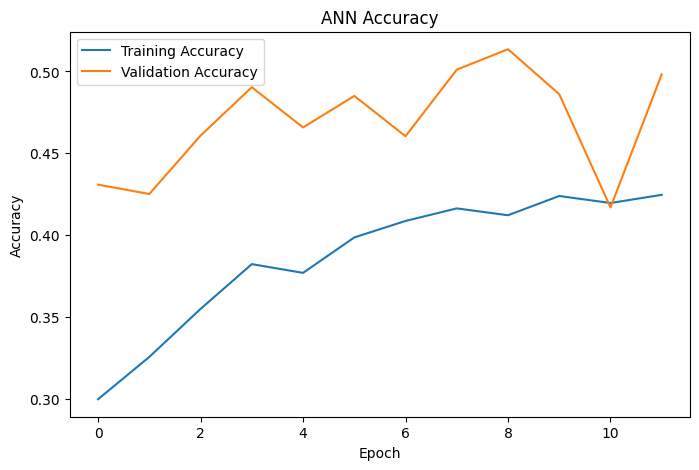

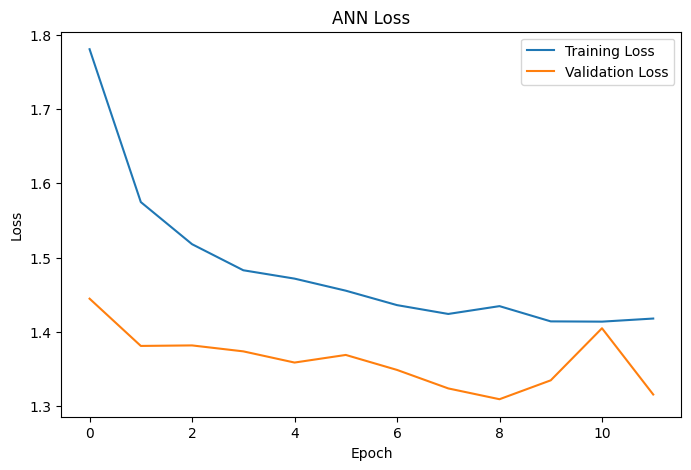

In [41]:
plot_training_history(
    ann_history,
    "ANN"
)

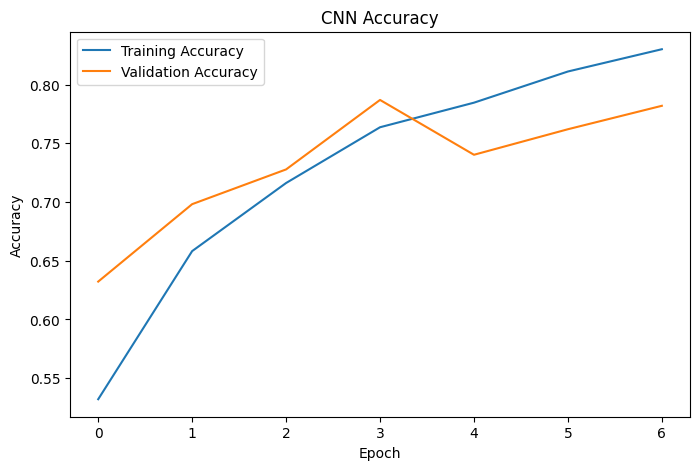

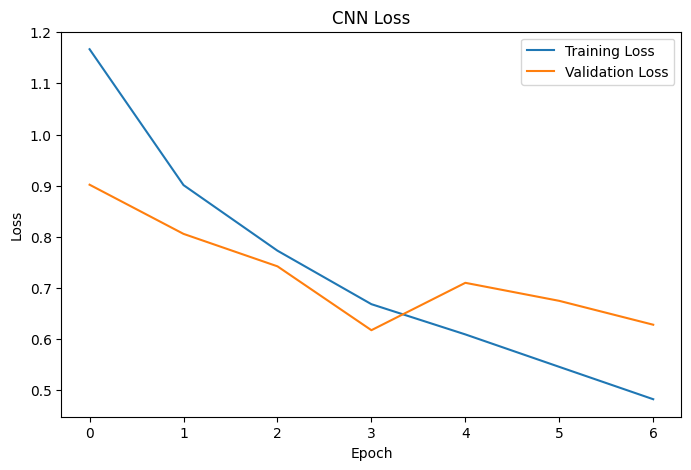

In [42]:
plot_training_history(
    cnn_history,
    "CNN"
)

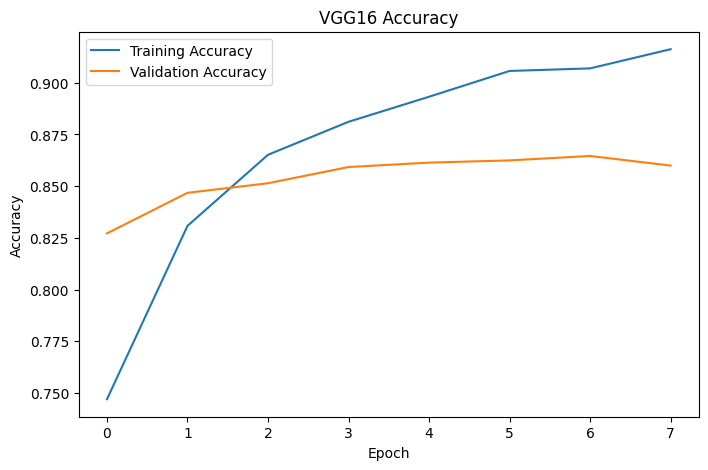

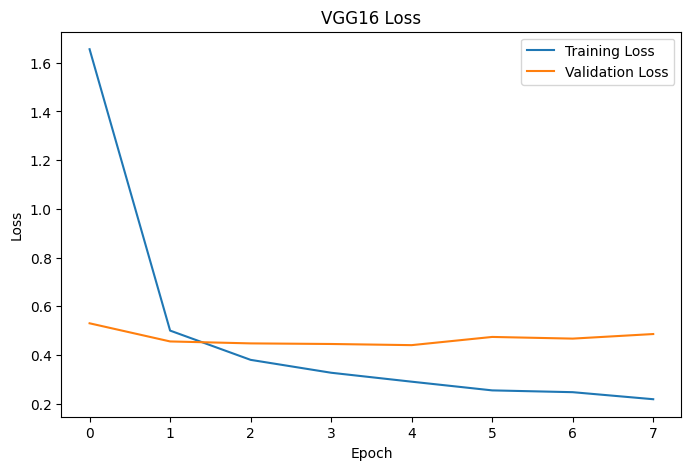

In [43]:
plot_training_history(
    vgg16_history,
    "VGG16"
)

In [44]:
def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: list[str],
    model_name: str
) -> None:

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        cmap="Blues",
        xticks_rotation=45
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

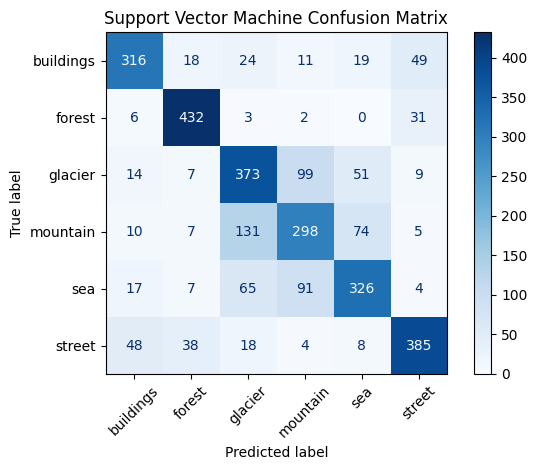

In [48]:
plot_confusion_matrix(
    y_true=y_test_ml,
    y_pred=ml_predictions["Support Vector Machine"],
    class_names=CLASS_NAMES,
    model_name="Support Vector Machine"
)

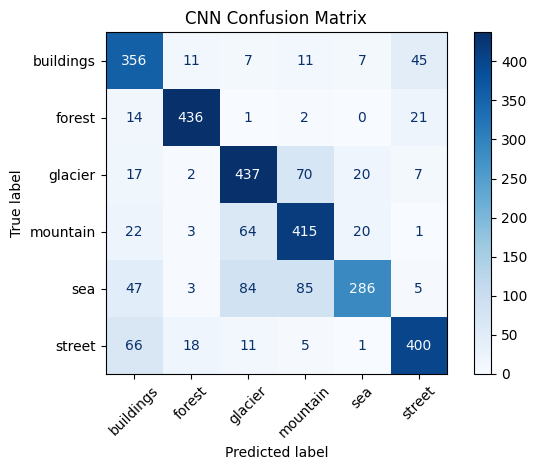

In [45]:
plot_confusion_matrix(
    y_true=y_test_ml,
    y_pred=cnn_predictions,
    class_names=CLASS_NAMES,
    model_name="CNN"
)

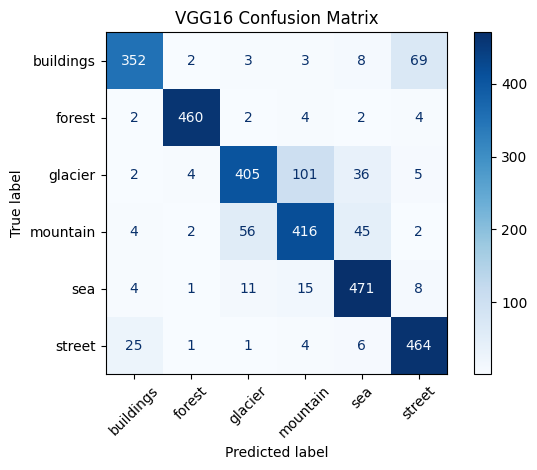

In [47]:
plot_confusion_matrix(
    y_true=y_test_ml,
    y_pred=vgg16_predictions,
    class_names=CLASS_NAMES,
    model_name="VGG16"
)

# Models Comparison

In [49]:
def compare_models(
    results: list[dict]
) -> pd.DataFrame:

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="F1 Score",
        ascending=False
    ).reset_index(drop=True)

    metric_columns = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

    results_df[metric_columns] = (
        results_df[metric_columns].round(4)
    )

    results_df["Training Time"] = (
        results_df["Training Time"].round(2)
    )

    return results_df

In [50]:
comparison_df = compare_models(model_results)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,VGG16,0.8560,0.8580,0.8560,0.8550,83.31
1,CNN,0.7767,0.7869,0.7767,0.7749,25.71
2,Support Vector Machine,0.7100,0.7104,0.7100,0.7094,95.15
3,Random Forest,0.6427,0.6446,0.6427,0.6410,81.40
4,Logistic Regression,0.5780,0.5776,0.5780,0.5775,117.31
5,ANN,0.5057,0.4659,0.5057,0.4675,22.69
6,Decision Tree,0.4393,0.4390,0.4393,0.4391,42.92
7,K-Nearest Neighbors,0.4443,0.5667,0.4443,0.3992,0.03


In [51]:
def visualize_model_comparison(
    results_df: pd.DataFrame
) -> None:

    metrics = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]

    comparison_plot = results_df.set_index("Model")[metrics]

    comparison_plot.plot(
        kind="bar",
        figsize=(14, 6)
    )

    plt.title("Model Performance Comparison")
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.legend(title="Metric")
    plt.tight_layout()
    plt.show()

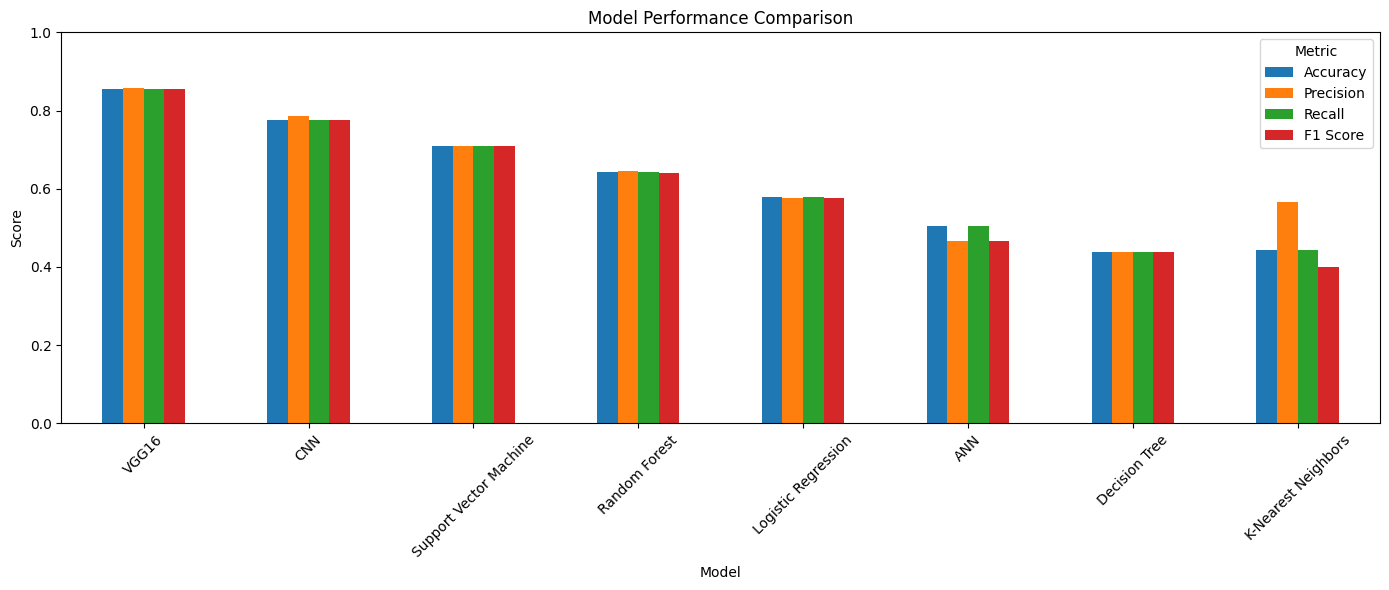

In [52]:
visualize_model_comparison(
    comparison_df
)

In [53]:
# compare training time
def visualize_training_time(
    results_df: pd.DataFrame
) -> None:

    plt.figure(figsize=(12, 6))

    plt.bar(
        results_df["Model"],
        results_df["Training Time"]
    )

    plt.title("Model Training Time Comparison")
    plt.xlabel("Model")
    plt.ylabel("Training Time (seconds)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

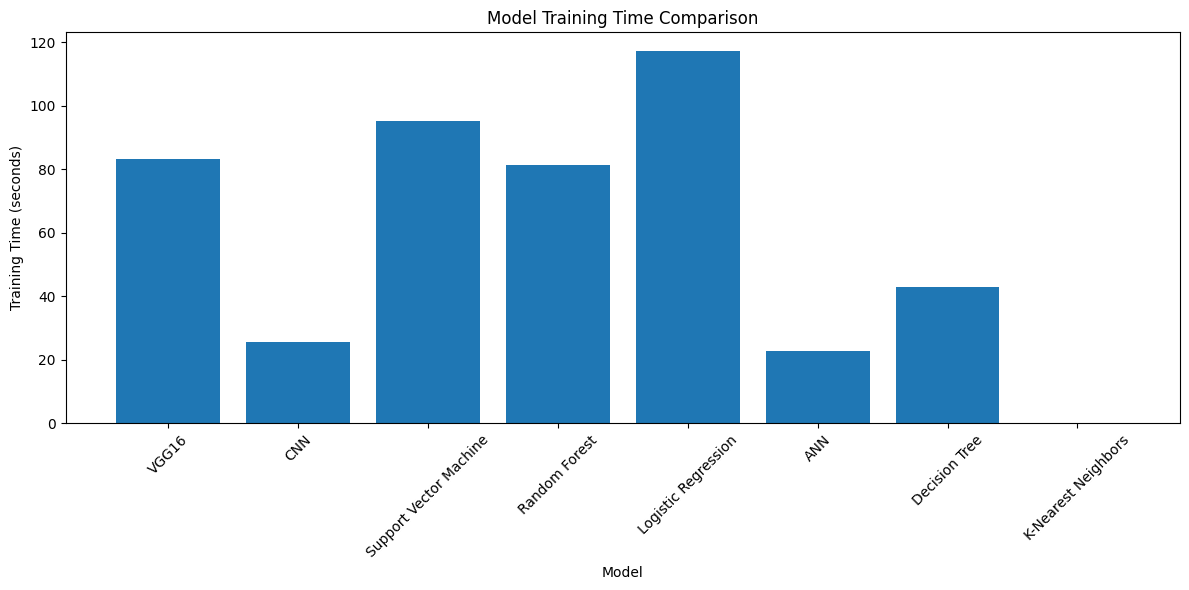

In [54]:
visualize_training_time(
    comparison_df
)

In [55]:
# best model
def display_best_model(
    results_df: pd.DataFrame
) -> None:

    if results_df.empty:
        print("No model results found.")
        return

    best_model = results_df.iloc[0]

    print("Best Model")
    print("=" * 40)

    print(f"Model:         {best_model['Model']}")
    print(f"Accuracy:      {best_model['Accuracy']}")
    print(f"Precision:     {best_model['Precision']}")
    print(f"Recall:        {best_model['Recall']}")
    print(f"F1 Score:      {best_model['F1 Score']}")
    print(
        f"Training Time: {best_model['Training Time']} seconds"
    )

In [56]:
display_best_model(
    comparison_df
)

Best Model
Model:         VGG16
Accuracy:      0.856
Precision:     0.858
Recall:        0.856
F1 Score:      0.855
Training Time: 83.31 seconds


# Save comparison results and save model for streamlit

In [57]:
comparison_df.to_csv(
    "/kaggle/working/model_comparison.csv",
    index=False
)

In [58]:
import joblib
for model_name, model in trained_models.items():

    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

    joblib.dump(
        model,
        f"/kaggle/working/{safe_name}.pkl"
    )

In [59]:
joblib.dump(
    hog_scaler,
    "/kaggle/working/hog_scaler.pkl"
)

['/kaggle/working/hog_scaler.pkl']

In [60]:
ann_model.save(
    "/kaggle/working/ann_model.keras"
)

cnn_model.save(
    "/kaggle/working/cnn_model.keras"
)

vgg16_model.save(
    "/kaggle/working/vgg16_model.keras"
)